# TikTok Trending Videos (Kaggle) — Exploratory Data Analysis

**Business question:** *What do trending TikTok videos look like, and which attributes (length, hashtags, caption, sound, creator size, posting time) go along with higher engagement among videos that already trended?*

**Dataset:** [TikTok Trending Videos by erikvdven](https://www.kaggle.com/datasets/erikvdven/tiktok-trending-december-2020) — *"First 1000 trending videos scraped from TikTok"* with an unofficial scraper and `trending.json` (the metadata). 

---
# Step 0 — Download and load the data



In [1]:
import json
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
TT_RED, TT_CYAN = "#EE1D52", "#69C9D0"

SEED = 42
DATA_DIR, OUT_DIR = Path("data"), Path("outputs")
DATA_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

LOCAL_TZ = "UTC"      # the data has no location info, so I keep UTC 
MIN_GROUP = 15        # groups smaller than this are flagged as unreliable in the charts and tables
MIN_TAG_N = 10        # a hashtag must appear in at least this many videos to be ranked by engagement
OVERRIDES = {}        # manual column mapping if auto-detection picks wrongly

In [ ]:
def find_metadata_file(root: Path) -> Path:
    """Find the metadata JSON under `root` (prefers a file with 'trend' in its name, then the largest)."""
    candidates = [p for p in root.rglob("*") if p.suffix.lower() in {".json", ".jsonl"}]
    if not candidates:
        raise FileNotFoundError(f"No .json file found under {root.resolve()}. See Step 0 for how to download it.")
    named = [p for p in candidates if "trend" in p.name.lower()]
    return max(named or candidates, key=lambda p: p.stat().st_size)


def load_records(path: Path) -> list:
    """Load a JSON array, a JSON object that wraps a list of records, or JSON Lines."""
    text = path.read_text(encoding="utf-8")
    try:
        obj = json.loads(text)
    except json.JSONDecodeError:
        obj = [json.loads(line) for line in text.splitlines() if line.strip()]
    if isinstance(obj, dict):
        lists = [v for v in obj.values() if isinstance(v, list) and v and isinstance(v[0], dict)]
        obj = max(lists, key=len) if lists else [obj]
    return obj


DATA_FILE = find_metadata_file(DATA_DIR)
print(f"Using: {DATA_FILE}  ({DATA_FILE.stat().st_size / 1e6:,.1f} MB)")

records = load_records(DATA_FILE)
raw = pd.json_normalize(records, sep=".")          
print(f"{len(raw):,} records x {raw.shape[1]} columns\n")

# Columns and how many rows have a value 
overview = pd.DataFrame({"non_null": raw.notna().sum(), "example_type": raw.apply(
    lambda s: type(s.dropna().iloc[0]).__name__ if s.notna().any() else "all missing")})
display(overview)

Using: data/trending.json  (3.0 MB)
1,000 records x 34 columns



,non_null,example_type
id,1000,str
text,1000,str
createTime,1000,int64
webVideoUrl,1000,str
videoUrl,1000,str
videoUrlNoWaterMark,1000,str
diggCount,1000,int64
shareCount,1000,int64
playCount,1000,int64
commentCount,1000,int64


---
# Step 1 — Map columns and clean

### 1.1 Column mapping

In [3]:
CANDIDATES = {
    "video_id":           ["id", "video_id", "videoId"],
    "caption":            ["text", "desc", "description", "video_title"],
    "create_time":        ["createTime", "create_time", "createTimeISO", "posted_time"],
    "views":              ["playCount", "plays", "views", "stats.playCount"],
    "likes":              ["diggCount", "likes", "stats.diggCount"],
    "comments":           ["commentCount", "comments", "stats.commentCount"],
    "shares":             ["shareCount", "shares", "stats.shareCount"],
    "duration":           ["videoMeta.duration", "duration", "video.duration", "video_length"],
    "hashtags":           ["hashtags"],
    "mentions":           ["mentions"],
    "author_followers":   ["authorMeta.fans", "authorMeta.followerCount", "authorStats.followerCount", "user_followers"],
    "author_total_likes": ["authorMeta.heart", "authorMeta.heartCount", "authorStats.heartCount"],
    "author_videos":      ["authorMeta.video", "authorMeta.videoCount", "authorStats.videoCount"],
    "author_verified":    ["authorMeta.verified", "author.verified"],
    "music_original":     ["musicMeta.musicOriginal", "music.original", "musicMeta.original"],
    "music_name":         ["musicMeta.musicName", "music.title"],
}
CANDIDATES.update({k: [v] for k, v in OVERRIDES.items()})        


def resolve(options):
    return next((c for c in options if c in raw.columns), None)


COLMAP = {std: resolve(opts) for std, opts in CANDIDATES.items()}
mapping = pd.DataFrame({
    "source_column": COLMAP,
    "non_null_%": {std: (100 * raw[src].notna().mean() if src else 0.0) for std, src in COLMAP.items()},
})
display(mapping)

missing_required = [k for k in ("views", "likes") if COLMAP[k] is None]
if missing_required:
    raise KeyError(f"Could not find {missing_required}. Look at the column list above and set OVERRIDES.")

df = pd.DataFrame({std: raw[src] for std, src in COLMAP.items() if src})
for std in CANDIDATES:
    if std not in df.columns:
        df[std] = np.nan                                             


def have(*cols):
    """True if every column exists and has at least one non-missing value."""
    return all(c in df.columns and df[c].notna().any() for c in cols)

,source_column,non_null_%
video_id,id,100.00
caption,text,100.00
create_time,createTime,100.00
views,playCount,100.00
likes,diggCount,100.00
comments,commentCount,100.00
shares,shareCount,100.00
duration,videoMeta.duration,100.00
hashtags,hashtags,100.00
mentions,mentions,100.00


### 1.2 Cleaning decisions 

| Issue | Decision | Rationale |
|---|---|---|
| Numbers may be stored as text | `pd.to_numeric(errors="coerce")` | Wrong dtypes silently break arithmetic. Bad values become `NaN` and are counted, not crashed on |
| `createTime` is Unix seconds (or ISO text) | Parse to UTC datetimes | Enables hour / weekday features |
| Same video twice | Keep the first occurrence | A video must count once |
| Missing views or likes | Drop | Engagement rate can't be computed |
| Zero views | Drop | Division by zero |
| Likes > views | Drop | Logically inconsistent counts |
| Missing comments / shares | Treat as 0 *only inside the engagement rate* and say so | Don't lose a video over one missing metric, but be transparent |
| Missing caption / hashtag list | Empty caption / no hashtags | "None" is a real value |
| Extreme (viral) values | **Keep** | They are real, and in trending data the extremes are the story. We use medians and log scales instead of deleting them |



In [4]:
# --- types ---
for c in ["views", "likes", "comments", "shares", "duration", "author_followers", "author_total_likes", "author_videos"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

ct_numeric = pd.to_numeric(df["create_time"], errors="coerce")
if ct_numeric.notna().any():
    df["created_utc"] = pd.to_datetime(ct_numeric, unit="s", utc=True, errors="coerce")
else:                                                                
    df["created_utc"] = pd.to_datetime(df["create_time"], utc=True, errors="coerce")

def to_flag(series):
    """True/False/NaN from booleans or 'true'/'false'/'t'/'f' strings (unknown stays NaN, not False)."""
    lookup = {True: True, False: False, "true": True, "false": False, "t": True, "f": False, "1": True, "0": False}
    return series.map(lambda v: lookup.get(v.strip().lower() if isinstance(v, str) else v, np.nan))

df["author_verified"] = to_flag(df["author_verified"])
df["music_original"] = to_flag(df["music_original"])
df["caption"] = df["caption"].fillna("").astype(str)

# --- row-level rules
cleaning_log = []
def log_step(label, before, after):
    cleaning_log.append({"step": label, "rows_before": before, "rows_after": after, "removed": before - after})

n = len(df)
if df["video_id"].notna().any():
    df = df.drop_duplicates(subset="video_id", keep="first")
log_step("duplicate video ids", n, len(df)); n = len(df)

df = df.dropna(subset=["views", "likes"])
log_step("missing views or likes", n, len(df)); n = len(df)

df = df[df["views"] > 0]
log_step("zero (or negative) views", n, len(df)); n = len(df)

df = df[(df["likes"] >= 0) & (df["likes"] <= df["views"])]
log_step("negative likes, or likes > views", n, len(df)); n = len(df)

df = df.reset_index(drop=True)
display(pd.DataFrame(cleaning_log))
print(f"Kept {len(df):,} of {len(raw):,} rows")
for c in ["comments", "shares"]:
    if df[c].isna().any():
        print(f"Note: {int(df[c].isna().sum())} rows have no '{c}'; they count as 0 inside the engagement rate.")

,step,rows_before,rows_after,removed
0,duplicate video ids,1000,1000,0
1,missing views or likes,1000,1000,0
2,zero (or negative) views,1000,1000,0
3,"negative likes, or likes > views",1000,1000,0


Kept 1,000 of 1,000 rows


---
# Step 2 — Engineer features

| Feature | Definition | Why |
|---|---|---|
| `engagement_rate` | (likes + comments + shares) / views | Reach-adjusted engagement. Raw likes mostly measure how many people saw the video |
| `like_rate`, `comment_rate`, `share_rate` | each metric / views | Shows *how* people engage (liking is cheap, commenting and sharing are higher effort) |
| `hashtag_count`, `hashtag_list` | from the structured `hashtags` list (regex on the caption as a fallback) | Structured data is more reliable than regex on free text |
| `caption_length` | characters in the caption | Short vs long captions |
| `duration_bucket` | `<15s, 15-30s, 30s+`| Ordered categories are easier to compare. We check each bucket has enough videos |
| `follower_tier` | `<100K`, `100K-1M`, `1M-10M`, `10M+` followers | Do only big creators trend? |
| `sound_type` | original sound vs other | Does using a creator's own sound matter? |
| `posting_hour`, `posting_weekday`, `daypart` | from `createTime` | Timing patterns (UTC) |


In [ ]:
# --- engagement ---
df["interactions"] = df["likes"] + df["comments"].fillna(0) + df["shares"].fillna(0)
df["engagement_rate"] = df["interactions"] / df["views"]
df["engagement_rate_pct"] = 100 * df["engagement_rate"]
df["like_rate_pct"] = 100 * df["likes"] / df["views"]
df["comment_rate_pct"] = 100 * df["comments"] / df["views"]
df["share_rate_pct"] = 100 * df["shares"] / df["views"]

# --- hashtags / mentions / caption ---
def tag_list(tags, caption):
    names = []
    if isinstance(tags, (list, tuple)):
        for h in tags:
            name = h.get("name") or h.get("title") if isinstance(h, dict) else h
            if name:
                names.append(str(name).lower().lstrip("#"))
    if not names:                                                      
        names = [t.lower() for t in re.findall(r"#(\w+)", caption)]
    return names

df["hashtag_list"] = pd.Series([tag_list(t, c) for t, c in zip(df["hashtags"], df["caption"])],
                               index=df.index, dtype="object")
df["hashtag_count"] = df["hashtag_list"].map(len)
df["mentions_count"] = df["mentions"].map(lambda m: len(m) if isinstance(m, (list, tuple)) else 0)
df["caption_length"] = df["caption"].str.len()

# --- duration ---
df["duration_bucket"] = pd.cut(df["duration"], bins=[0, 15, 30, np.inf], right=False, ordered=True,
                               labels=["<15s", "15-30s", "30s+"])

# --- creator ---
df["sound_type"] = df["music_original"].map({True: "original sound", False: "other sound"})
df["verified_label"] = df["author_verified"].map({True: "verified", False: "not verified"})

# --- timing ---
local = df["created_utc"].dt.tz_convert(LOCAL_TZ)
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
df["posting_hour"] = local.dt.hour
df["posting_weekday"] = pd.Categorical(local.dt.day_name(), categories=weekday_order, ordered=True)
df["daypart"] = pd.cut(df["posting_hour"], bins=[-1, 5, 11, 17, 23], ordered=True,
                       labels=["night (0-5)", "morning (6-11)", "afternoon (12-17)", "evening (18-23)"])
df["age_days_rel"] = (df["created_utc"].max() - df["created_utc"]).dt.total_seconds() / 86400

# --- binned versions used in the charts ---
df["hashtag_bin"] = pd.cut(df["hashtag_count"], bins=[-1, 0, 2, 4, 7, np.inf], ordered=True,
                           labels=["0", "1-2", "3-4", "5-7", "8+"])
df["caption_len_quintile"] = pd.qcut(df["caption_length"].rank(method="first"), 5,
                                     labels=["Q1 (shortest)", "Q2", "Q3", "Q4", "Q5 (longest)"])

# --- sanity checks: do the buckets have enough videos? ---
for col in ["duration_bucket", "follower_tier", "hashtag_bin"]:
    if have(col):
        counts = df[col].value_counts(sort=False)
        flag = " <-- some groups are small; consider merging bins" if (counts < MIN_GROUP).any() else ""
        print(f"{col}: {counts.to_dict()}{flag}")
assert (df["engagement_rate"] >= 0).all()
print("\nFeatures created for", len(df), "videos.")

duration_bucket: {'<15s': 501, '15-30s': 330, '30s+': 169}
hashtag_bin: {'0': 147, '1-2': 126, '3-4': 176, '5-7': 266, '8+': 285}

Features created for 1000 videos.


In [6]:
def boot_median_ci(x, n_boot=2000, alpha=0.05, seed=SEED):
    """Median and bootstrap (1-alpha) CI."""
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    if len(x) < 5:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    meds = np.median(x[rng.integers(0, len(x), size=(n_boot, len(x)))], axis=1)
    lo, hi = np.quantile(meds, [alpha / 2, 1 - alpha / 2])
    return float(np.median(x)), float(lo), float(hi)


def group_median_ci(col, value="engagement_rate_pct"):
    rows = []
    for key, g in df.groupby(col, observed=True):
        med, lo, hi = boot_median_ci(g[value])
        rows.append({"group": str(key), "n": len(g), "median": med, "ci_low": lo, "ci_high": hi})
    out = pd.DataFrame(rows)
    if len(out):
        out["reliable"] = out["n"] >= MIN_GROUP
    return out


def plot_median_ci(ax, col, title, value="engagement_rate_pct", ylabel="Median engagement rate (%)"):
    t = group_median_ci(col, value)
    t = t[t["n"] >= 5]
    x = np.arange(len(t))
    colors = [TT_CYAN if ok else "#cccccc" for ok in t["reliable"]]           
    ax.bar(x, t["median"], color=colors)
    ax.errorbar(x, t["median"], yerr=[t["median"] - t["ci_low"], t["ci_high"] - t["median"]],
                fmt="none", ecolor="black", capsize=3)
    ax.set_xticks(x)
    ax.set_xticklabels([f"{g}\n(n={n})" for g, n in zip(t["group"], t["n"])], fontsize=8)
    ax.set(title=title, ylabel=ylabel)

### 3.1 Distributions and summary statistics

,count,mean,std,min,10%,25%,50%,75%,90%,99%,max,skew
views,"1,000.00","1,029,212.94","9,017,676.40",465.00,"26,190.00","46,875.00","82,500.00","218,800.00","867,330.00","19,124,000.00","250,800,000.00",22.54
likes,"1,000.00","96,797.88","1,043,486.70",13.00,"1,250.50","2,864.50","7,412.50","22,850.00","84,650.00","938,838.00","31,000,000.00",26.50
comments,"1,000.00","1,271.54","19,962.89",0.00,16.90,46.00,123.00,372.25,"1,008.90","11,105.00","625,700.00",30.73
shares,"1,000.00","1,905.36","11,314.63",0.00,6.00,20.00,80.00,388.25,"1,879.20","45,907.00","220,100.00",12.62
engagement_rate_pct,"1,000.00",10.41,7.09,0.35,3.05,5.49,8.89,13.31,19.77,33.60,49.73,1.50


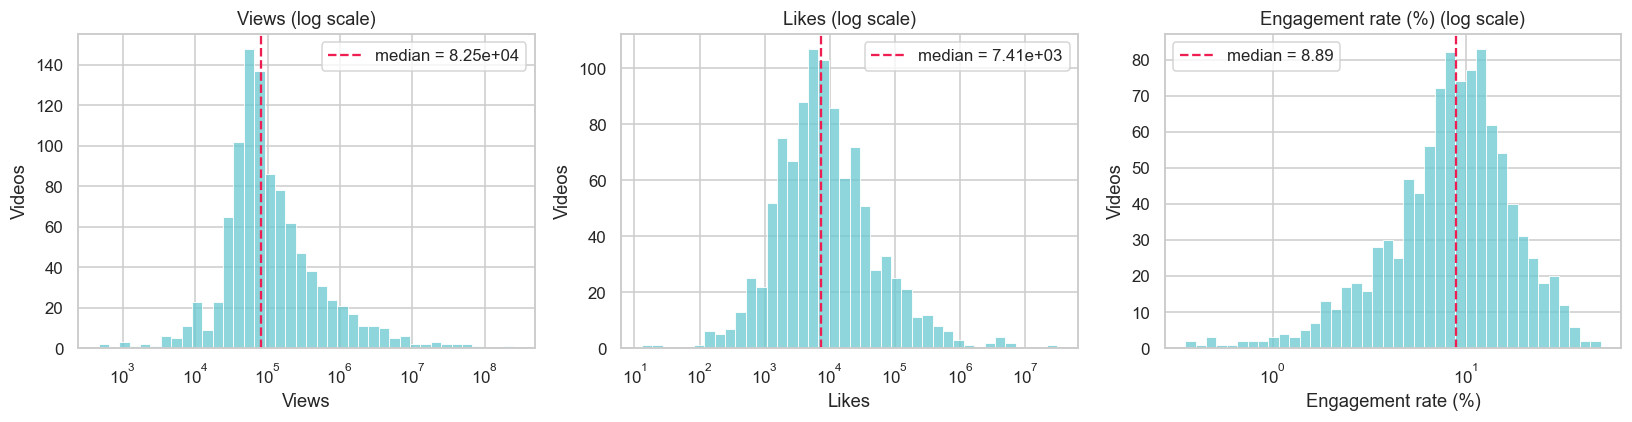

In [7]:
metrics = ["views", "likes", "comments", "shares", "engagement_rate_pct"]
metrics = [m for m in metrics if have(m)]
summary = df[metrics].describe(percentiles=[.1, .25, .5, .75, .9, .99]).T
summary["skew"] = df[metrics].skew()
display(summary)

plots = [("views", "Views"), ("likes", "Likes"), ("engagement_rate_pct", "Engagement rate (%)")]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (col, title) in zip(axes, plots):
    data = df.loc[df[col] > 0, col]
    sns.histplot(data, bins=40, log_scale=True, color=TT_CYAN, ax=ax)
    ax.axvline(data.median(), color=TT_RED, ls="--", label=f"median = {data.median():,.3g}")
    ax.set(title=f"{title} (log scale)", xlabel=title, ylabel="Videos")
    ax.legend()
plt.tight_layout()
plt.show()

### 3.2 How concentrated is attention?

Top 10% of videos hold 88.3% of all views | top 1% hold 60.1% | Gini = 0.904


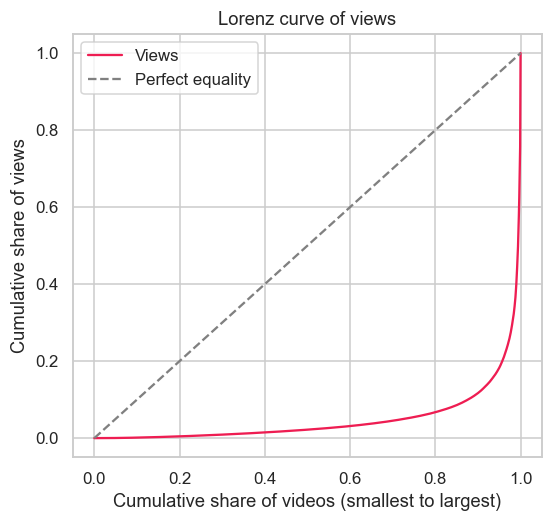

In [8]:
def gini(values):
    x = np.sort(np.asarray(values, float))
    n = len(x)
    return float((2 * np.arange(1, n + 1) - n - 1) @ x / (n * x.sum()))

v = np.sort(df["views"].to_numpy(float))[::-1]
top10 = 100 * v[: max(1, int(len(v) * 0.10))].sum() / v.sum()
top1 = 100 * v[: max(1, int(len(v) * 0.01))].sum() / v.sum()
print(f"Top 10% of videos hold {top10:.1f}% of all views | top 1% hold {top1:.1f}% | Gini = {gini(v):.3f}")

x = np.sort(df["views"].to_numpy(float))
cum_share = np.r_[0, np.cumsum(x) / x.sum()]
pop_share = np.linspace(0, 1, len(cum_share))
plt.figure(figsize=(5.5, 5))
plt.plot(pop_share, cum_share, color=TT_RED, label="Views")
plt.plot([0, 1], [0, 1], color="grey", ls="--", label="Perfect equality")
plt.xlabel("Cumulative share of videos (smallest to largest)")
plt.ylabel("Cumulative share of views")
plt.title("Lorenz curve of views")
plt.legend()
plt.show()

### 3.3 How do the metrics relate?
- **Views vs likes** (log-log): points along a straight line mean likes scale with views; the *spread* around the line is what engagement rate captures.
- **Views vs engagement rate:** a negative relationship is common because the biggest videos reach many casual viewers who don't interact.
- The **Spearman correlation matrix** uses ranks, so it isn't thrown off by skew. Rough guide: |ρ| below 0.1 negligible, 0.1-0.3 weak, above 0.5 strong.

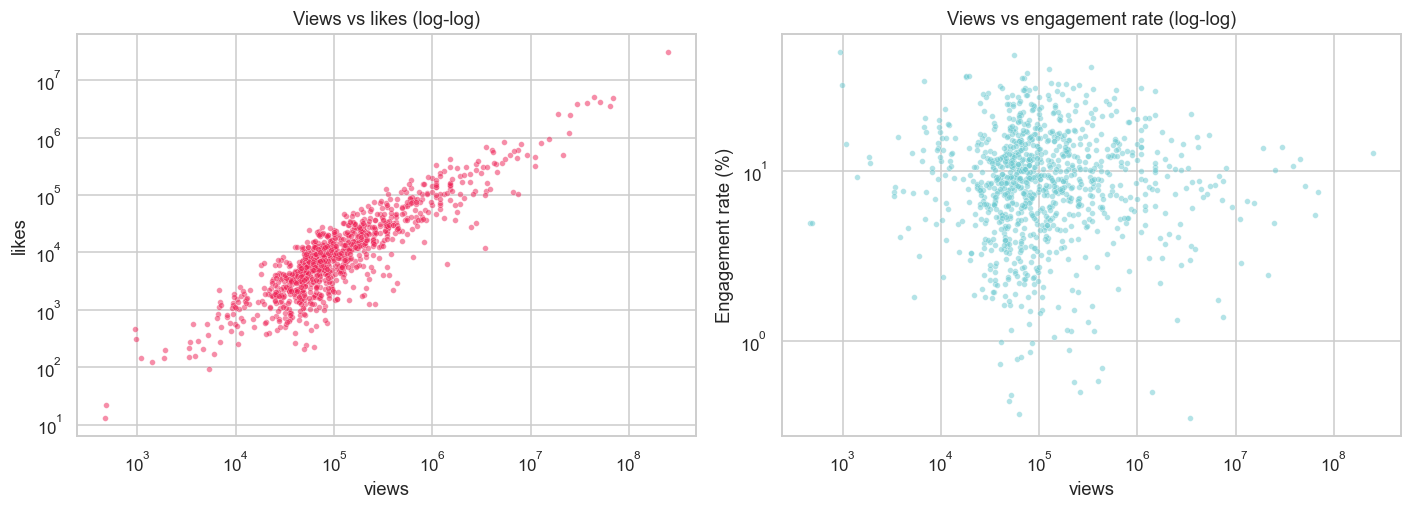

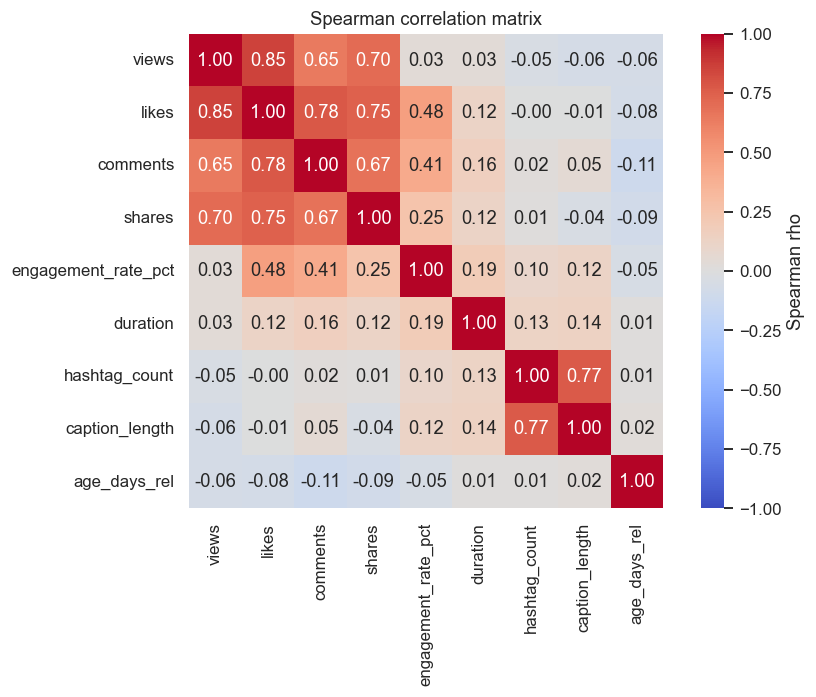

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
sns.scatterplot(data=df, x="views", y="likes", s=14, alpha=.5, color=TT_RED, ax=axes[0])
axes[0].set(xscale="log", yscale="log", title="Views vs likes (log-log)")
sns.scatterplot(data=df, x="views", y="engagement_rate_pct", s=14, alpha=.5, color=TT_CYAN, ax=axes[1])
axes[1].set(xscale="log", yscale="log", title="Views vs engagement rate (log-log)", ylabel="Engagement rate (%)")
plt.tight_layout()
plt.show()

corr_candidates = ["views", "likes", "comments", "shares", "engagement_rate_pct", "duration", "hashtag_count",
                   "caption_length", "author_followers", "age_days_rel"]
corr_cols = [c for c in corr_candidates if have(c)]
corr = df[corr_cols].corr(method="spearman")
plt.figure(figsize=(8.5, 6.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={"label": "Spearman rho"})
plt.title("Spearman correlation matrix")
plt.tight_layout()
plt.show()

### 3.4 *How* do people engage? Like, comment and share rates
Liking is cheap; commenting and sharing take more effort. Comparing the three rates shows what kind of engagement these videos get. Medians again, because the rates are skewed.

,median,ci_low,ci_high
like_rate_pct,8.45,8.05,8.86
comment_rate_pct,0.13,0.11,0.14
share_rate_pct,0.09,0.08,0.10


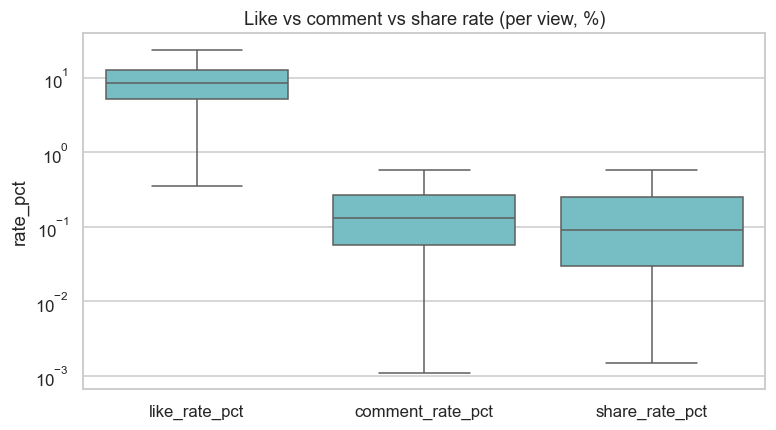

In [10]:
rate_cols = [c for c in ["like_rate_pct", "comment_rate_pct", "share_rate_pct"] if have(c)]
rates = pd.DataFrame({c: boot_median_ci(df[c]) for c in rate_cols}, index=["median", "ci_low", "ci_high"]).T
display(rates)

if len(rate_cols) > 1:
    melted = df[rate_cols].melt(var_name="metric", value_name="rate_pct")
    melted = melted[melted["rate_pct"] > 0]
    plt.figure(figsize=(8, 4.2))
    sns.boxplot(data=melted, x="metric", y="rate_pct", showfliers=False, color=TT_CYAN)
    plt.yscale("log")
    plt.title("Like vs comment vs share rate (per view, %)")
    plt.xlabel("")
    plt.show()

### 3.5 Creator size: do only big accounts trend?
Two questions: (1) **what share of trending videos come from small accounts?** and (2) **does engagement rate fall as accounts get bigger?** A common pattern is that large accounts get more views but a *lower* engagement rate. The scatter uses followers vs views and vs engagement rate on log axes, with the Spearman ρ in each title.

In [11]:
creator_counts = raw["authorMeta.id"].value_counts()
print(f"{len(raw):,} videos from {creator_counts.size:,} distinct creators")
print(f"Creators with 2+ videos in the list: {(creator_counts >= 2).sum():,} "
      f"({100 * (creator_counts >= 2).mean():.1f}% of creators)")
print(f"The 10 most frequent creators account for "
      f"{100 * creator_counts.head(10).sum() / len(raw):.1f}% of videos")

1,000 videos from 802 distinct creators
Creators with 2+ videos in the list: 91 (11.3% of creators)
The 10 most frequent creators account for 10.5% of videos


### 3.6 Content features: length, hashtags, caption, sound, verified
Each bar is a **median engagement rate** with its 95% bootstrap CI. **Grey bars** have fewer than `MIN_GROUP` videos and should not be over-interpreted. These are *descriptive* comparisons that don't control for other factors (for example, longer videos may also come from bigger accounts).

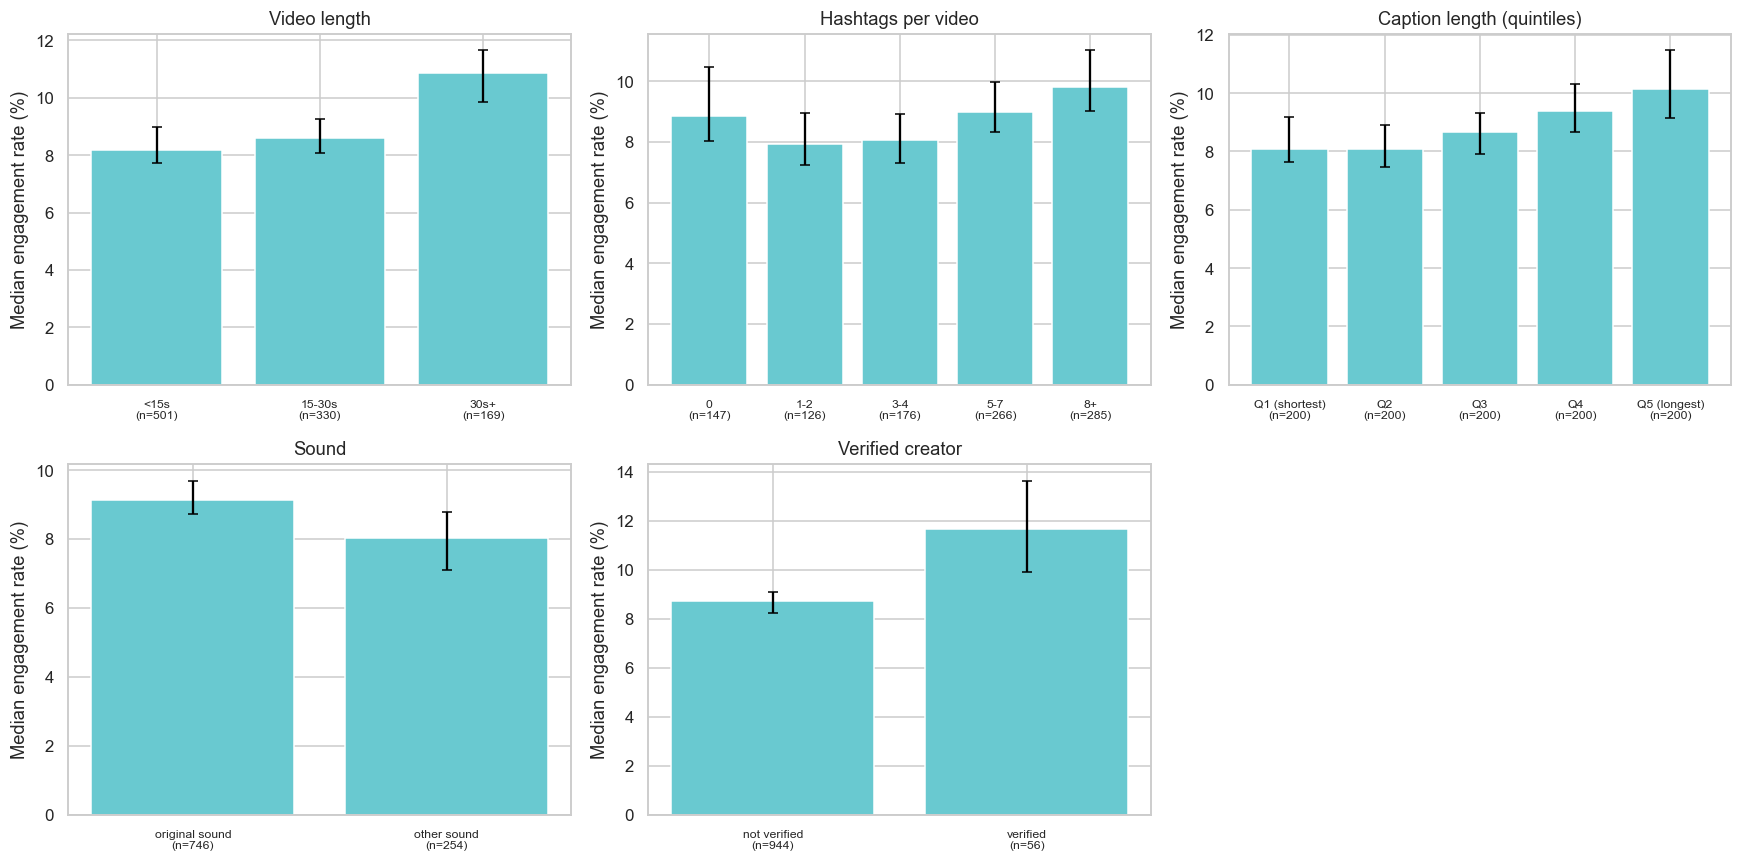

In [21]:
panels = [("duration_bucket", "Video length"), ("hashtag_bin", "Hashtags per video"),
          ("caption_len_quintile", "Caption length (quintiles)"), ("sound_type", "Sound"),
          ("verified_label", "Verified creator"), ("follower_tier", "Creator size")]
panels = [p for p in panels if have(p[0])]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax in axes.ravel()[len(panels):]:
    ax.axis("off")
for ax, (col, title) in zip(axes.ravel(), panels):
    plot_median_ci(ax, col, title)
plt.tight_layout()
plt.savefig(OUT_DIR / "content_features_ci.png", dpi=200, bbox_inches="tight")
plt.show()

### 3.7 When are trending videos posted?
Hours and weekdays are shown in the timezone set by `LOCAL_TZ` (UTC by default, because the dataset has no location information). Counts show *when trending videos were posted*, not when posting is best, since we have no data on non-trending posts.

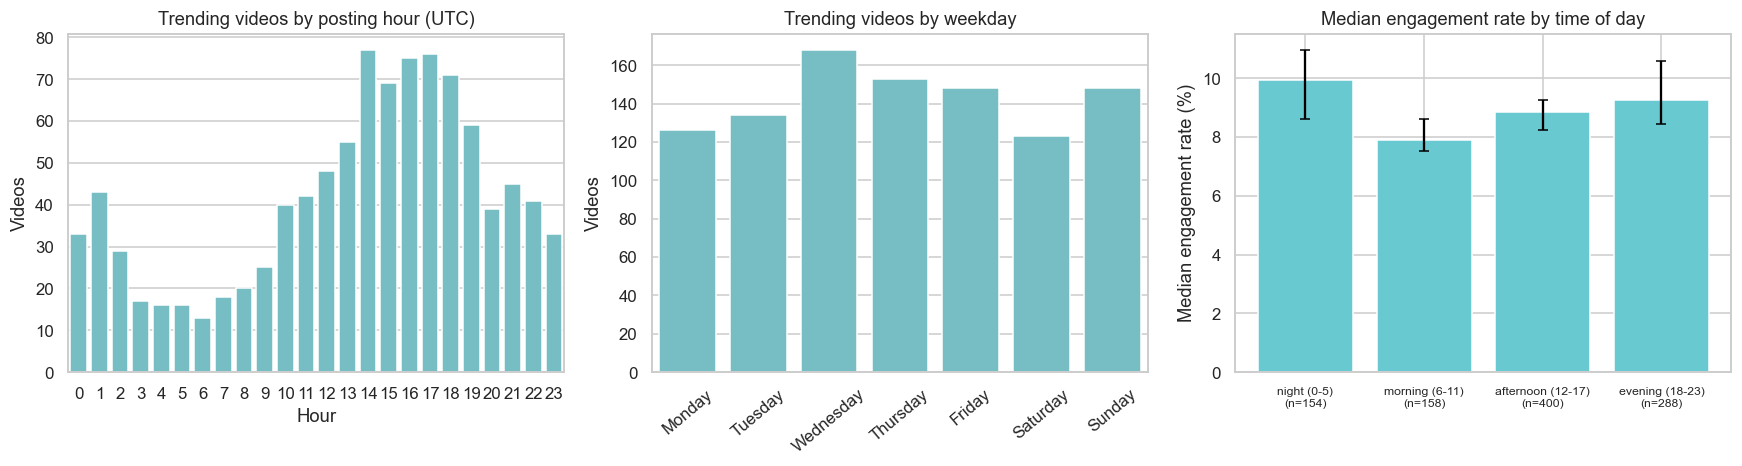

In [13]:
if have("posting_hour"):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
    sns.countplot(data=df, x="posting_hour", color=TT_CYAN, ax=axes[0])
    axes[0].set(title=f"Trending videos by posting hour ({LOCAL_TZ})", xlabel="Hour", ylabel="Videos")
    sns.countplot(data=df, x="posting_weekday", color=TT_CYAN, ax=axes[1])
    axes[1].set(title="Trending videos by weekday", xlabel="", ylabel="Videos")
    axes[1].tick_params(axis="x", rotation=40)
    plot_median_ci(axes[2], "daypart", "Median engagement rate by time of day")
    plt.tight_layout()
    plt.show()
else:
    print("No usable creation timestamps: skipping timing analysis.")

### 3.8 Hashtags and sounds

In [14]:
exploded = df[["video_id", "hashtag_list", "engagement_rate_pct", "views"]].explode("hashtag_list").rename(columns={"hashtag_list": "tag"})
exploded = exploded.dropna(subset=["tag"])
GENERIC_TAGS = {"fyp", "foryou", "foryoupage", "fy", "viral", "trending", "tiktok", "xyzbca", "fypシ"}

tag_stats = (exploded.groupby("tag")
             .agg(videos=("tag", "size"), median_er_pct=("engagement_rate_pct", "median"), median_views=("views", "median"))
             .query("videos >= @MIN_TAG_N")
             .assign(generic=lambda d: d.index.isin(GENERIC_TAGS))
             .sort_values("videos", ascending=False))
print(f"{exploded['tag'].nunique():,} distinct hashtags; {len(tag_stats)} appear in at least {MIN_TAG_N} videos")
display(tag_stats.head(15))
print("\nTop content hashtags by median engagement rate (generic reach tags excluded):")
display(tag_stats[~tag_stats["generic"]].sort_values("median_er_pct", ascending=False).head(10))

if have("music_name"):
    sounds = (df.dropna(subset=["music_name"]).groupby("music_name")
              .agg(videos=("video_id", "size"), median_er_pct=("engagement_rate_pct", "median"))
              .sort_values("videos", ascending=False).head(10))
    print("\nMost used sounds:")
    display(sounds)

2,220 distinct hashtags; 49 appear in at least 10 videos


,videos,median_er_pct,median_views,generic
tag,,,,
fyp,417,9.00,"85,900.00",True
foryou,272,8.42,"78,900.00",True
foryoupage,174,9.09,"73,050.00",True
fy,116,6.79,"86,950.00",True
fitness,87,8.98,"80,500.00",False
workout,73,9.01,"81,900.00",False
voorjou,72,7.93,"84,450.00",False
viral,65,8.04,"86,900.00",True
animeedit,63,21.25,"103,300.00",False



Top content hashtags by median engagement rate (generic reach tags excluded):


,videos,median_er_pct,median_views,generic
tag,,,,
equestrian,15,23.61,"105,700.00",False
edit,12,23.11,"70,500.00",False
weeb,10,21.49,"105,750.00",False
animeedit,63,21.25,"103,300.00",False
anime,50,21.24,"124,650.00",False
naruto,17,21.12,"143,700.00",False
otaku,13,18.53,"123,900.00",False
horse,32,14.76,"77,000.00",False
parati,17,14.54,"88,800.00",False



Most used sounds:


,videos,median_er_pct
music_name,,
original sound,324,9.21
origineel geluid,124,7.36
sonido original,27,20.01
оригинальный звук,25,12.24
som original,24,11.70
Therefore I Am,10,13.53
Oh No,8,7.44
Originalton,8,9.36
الصوت الأصلي,6,9.20


In [20]:
print(df["posting_hour"].value_counts().head(3))

posting_hour
14    77
17    76
16    75
Name: count, dtype: int64


---
# Step 4 — Statistical checks (with effect sizes)

**Effect sizes matter more than p-values.**
- Kruskal-Wallis: **epsilon-squared** (rough guide: 0.01 small, 0.06 medium, 0.14 large).
- Mann-Whitney: **rank-biserial r** = P(A>B) − P(B>A) (about 0.1 small, 0.3 medium, 0.5 large).

**With about 1,000 videos these tests have limited power.** A non-significant result means *"we can't tell"*, not *"there is no difference"*. Groups smaller than 5 videos are excluded.

In [15]:
def bh_adjust(p):
    """Benjamini-Hochberg adjusted p-values (q-values)."""
    p = np.asarray(p, float)
    order = np.argsort(p)
    ranked = p[order] * len(p) / (np.arange(len(p)) + 1)
    q = np.minimum.accumulate(ranked[::-1])[::-1]
    out = np.empty_like(q)
    out[order] = np.minimum(q, 1.0)
    return out


def compare(col, value="engagement_rate"):
    groups = {str(k): g[value].dropna().to_numpy() for k, g in df.groupby(col, observed=True)}
    groups = {k: v for k, v in groups.items() if len(v) >= 5}
    if len(groups) < 2:
        return None
    n = sum(len(v) for v in groups.values())
    if len(groups) == 2:
        (a, xa), (b, xb) = groups.items()
        U, p = stats.mannwhitneyu(xa, xb, alternative="two-sided")
        r = 2 * U / (len(xa) * len(xb)) - 1
        return {"feature": col, "test": f"Mann-Whitney ({a} vs {b})", "groups": 2, "n": n,
                "p_value": p, "effect_size": r, "effect_name": "rank-biserial r"}
    H, p = stats.kruskal(*groups.values())
    k = len(groups)
    return {"feature": col, "test": "Kruskal-Wallis", "groups": k, "n": n,
            "p_value": p, "effect_size": (H - k + 1) / (n - k), "effect_name": "epsilon-squared"}


features_to_test = ["duration_bucket", "follower_tier", "hashtag_bin", "caption_len_quintile",
                    "sound_type", "verified_label", "daypart", "posting_weekday"]
rows = [compare(c) for c in features_to_test if have(c)]
tests = pd.DataFrame([r for r in rows if r])
tests["q_value"] = bh_adjust(tests["p_value"])
tests = tests.sort_values("p_value").reset_index(drop=True)

tests_display = tests.copy()
for c in ["p_value", "q_value"]:
    tests_display[c] = tests_display[c].map(lambda p: f"{p:.3g}")
display(tests_display)

,feature,test,groups,n,p_value,effect_size,effect_name,q_value
0,duration_bucket,Kruskal-Wallis,3,1000,9.27e-07,0.03,epsilon-squared,6.49e-06
1,caption_len_quintile,Kruskal-Wallis,5,1000,0.000342,0.02,epsilon-squared,0.0012
2,hashtag_bin,Kruskal-Wallis,5,1000,0.000738,0.02,epsilon-squared,0.00139
3,sound_type,Mann-Whitney (original sound vs other sound),2,1000,0.000796,0.14,rank-biserial r,0.00139
4,verified_label,Mann-Whitney (not verified vs verified),2,1000,0.00179,-0.25,rank-biserial r,0.00251
5,daypart,Kruskal-Wallis,4,1000,0.00907,0.01,epsilon-squared,0.0106
6,posting_weekday,Kruskal-Wallis,7,1000,0.367,0.00,epsilon-squared,0.367


In [19]:
cols_top = ["video_id", "views", "likes", "engagement_rate_pct", "duration", "hashtag_count"]
cols_top = [c for c in cols_top if have(c)]
print("Top 10 videos by views :")
display(df.nlargest(10, "views")[cols_top])
print("\nTop 10 by engagement rate (views >= median views, to avoid tiny-reach noise):")
display(df[df["views"] >= df["views"].median()].nlargest(10, "engagement_rate_pct")[cols_top])

Top 10 videos by views :


,video_id,views,likes,engagement_rate_pct,duration,hashtag_count
947,6894081763379924229,250800000,31000000,12.70,9,1
706,6890571273110392065,68700000,5000000,7.46,14,2
197,6900606242016840962,64500000,3500000,5.53,12,0
608,6880410980434660610,50500000,4100000,8.18,14,5
349,6885766692627107077,44600000,5200000,11.80,12,0
848,6907943881829059841,37900000,4000000,10.64,10,1
722,6907971568165604610,29900000,3900000,13.80,8,6
430,6880196605513927938,25100000,2500000,10.11,40,12
244,6895082457968725249,24800000,1200000,4.91,7,7
145,6906741890503183621,21500000,500800,2.44,13,6



Top 10 by engagement rate (views >= median views, to avoid tiny-reach noise):


,video_id,views,likes,engagement_rate_pct,duration,hashtag_count
163,6903508885970193666,340500,129200,40.74,9,8
253,6903324940011916546,125400,46500,39.40,13,8
108,6901195423273291009,132800,42600,32.76,11,6
701,6879452591953153282,154600,48700,32.24,19,12
578,6890631109583867137,186800,58000,32.20,13,11
895,6891908752539274497,254800,74700,31.75,19,5
372,6888031153173892353,1100000,330000,30.68,11,9
550,6904037272048389378,222000,63600,30.52,12,9
473,6882419822806699266,90300,26900,30.44,23,10
267,6899171884571626753,351700,103900,30.20,26,12


---
# Step 5 — Insights, limitations, and export

### Insights template 
1. **Scale and concentration:** attention is extremely concentrated. The top 10% of trending videos hold 88.3% of all views and the top 1% (10 videos) hold 60.1% (Gini = 0.904). One video alone has about 251 million views.
2. **How people engage:** liking is far more common than commenting or sharing. The median like rate is 8.45% of views (95% CI 8.05-8.86), versus a comment rate of 0.13% (0.11-0.14) and a share rate of 0.09% (0.08-0.10).
3. **Creator concentration (no follower data in this file):** the 1,000 videos come from 802 distinct creators. Only 91 creators (11.3%) appear more than once, and the 10 most frequent creators account for 10.5% of videos, so no small group of creators dominates the list.
4. **Content features:** videos of 30 seconds or more have the highest median engagement rate (10.9%, 95% CI 9.8-11.6), and the CI does not overlap with videos under 15 seconds (8.2%, 7.7-9.0) or 15-30 seconds (8.6%, 8.1-9.2). Verified creators (only 56 videos) have a higher median (11.7%, CI 9.9-13.7) than non-verified creators (8.7%, CI 8.3-9.1). Longer, hashtag-heavy captions and original sounds also go with higher engagement, with smaller effects. All 10 of the highest-engagement videos (among those with at least median views) used 5 or more hashtags (median 9), but this is a top-10 illustration, not a general rule.
5. **Timing:** posting is spread fairly evenly through the afternoon and evening. The three busiest hours are 14:00, 17:00 and 16:00 UTC, with about 7.5% of videos each, and 40% of videos were posted between 12:00 and 17:59 UTC. Engagement differences by time of day were tiny, and there was no clear difference by weekday.
6. **Statistical check:** the strongest signal is verified status (rank-biserial r = -0.25, q = 0.0025), followed by video length (epsilon-squared about 0.03 in my earlier read-out; update this from your re-run Step 4 table). Both are small to moderate effects.



In [17]:
summary_frames = []
for col in ["duration_bucket", "follower_tier", "hashtag_bin", "caption_len_quintile",
            "sound_type", "verified_label", "daypart", "posting_weekday"]:
    if have(col):
        t = group_median_ci(col)
        t.insert(0, "feature", col)
        summary_frames.append(t)
summary_by_feature = pd.concat(summary_frames, ignore_index=True)
summary_by_feature.to_csv(OUT_DIR / "kaggle_er_summary_by_feature.csv", index=False)

tests.to_csv(OUT_DIR / "kaggle_statistical_tests.csv", index=False)
tag_stats.drop(columns="generic").to_csv(OUT_DIR / "kaggle_hashtag_stats.csv")
pd.DataFrame(cleaning_log).to_csv(OUT_DIR / "kaggle_cleaning_log.csv", index=False)

export_cols = ["video_id", "created_utc", "views", "likes", "comments", "shares", "interactions",
               "engagement_rate", "engagement_rate_pct", "like_rate_pct", "comment_rate_pct", "share_rate_pct",
               "duration", "duration_bucket", "hashtag_count", "mentions_count", "caption_length",
               "author_followers", "follower_tier", "sound_type", "verified_label",
               "posting_hour", "posting_weekday", "daypart", "age_days_rel"]
export_cols = [c for c in export_cols if c in df.columns]
features_out = df[export_cols].copy()
features_out["created_utc"] = features_out["created_utc"].dt.tz_localize(None)
features_out.to_csv(OUT_DIR / "kaggle_tiktok_features_for_tableau.csv", index=False)

print("Exported:", ", ".join(sorted(p.name for p in OUT_DIR.glob("kaggle_*.csv"))))

Exported: kaggle_cleaning_log.csv, kaggle_er_summary_by_feature.csv, kaggle_hashtag_stats.csv, kaggle_statistical_tests.csv, kaggle_tiktok_features_for_tableau.csv


In [22]:
tableau_cols = ["created_utc", "views", "likes", "comments", "shares",
                "engagement_rate_pct", "like_rate_pct", "comment_rate_pct", "share_rate_pct",
                "duration", "duration_bucket", "hashtag_count", "hashtag_bin",
                "caption_length", "caption_len_quintile",
                "sound_type", "verified_label", "posting_hour", "posting_weekday", "daypart"]
out = df[tableau_cols].copy()
out["created_utc"] = out["created_utc"].dt.tz_localize(None)
out.to_csv(OUT_DIR / "tiktok_tableau_final.csv", index=False)
print(out.shape)

(1000, 20)
